
# Bloque 3 — NLP con Reseñas Colombianas de Medellin

## Objetivos

- Preparacion del corpus
- Tokenizacion y limpieza textual
- TF-IDF y analisis estadistico
- Clasificacion con Regresion Logistica
- Comparacion con Hugging Face

## Dataset seleccionado

Se utilizaran reseñas reales de servicios y lugares de Medellin obtenidas desde Google Maps mediante scraping.



# Instalacion de dependencias


In [1]:

!pip install pandas numpy matplotlib seaborn scikit-learn nltk transformers wordcloud beautifulsoup4 requests -q



[notice] A new release of pip available: 22.2.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



# Importación de librerias


In [2]:

import pandas as pd
import numpy as np
import re
import nltk
import requests
import matplotlib.pyplot as plt
import seaborn as sns

from bs4 import BeautifulSoup
from collections import Counter
from wordcloud import WordCloud

from nltk.tokenize import RegexpTokenizer
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from transformers import pipeline

nltk.download('stopwords')

stop_words = set(stopwords.words('spanish'))


c:\Users\Josue\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Josue\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



# Parte A · Preparacion del corpus

## Scraping / Descarga del corpus

En esta seccion se construira un corpus textual colombiano utilizando reseñas de lugares de Medellin


In [3]:

# =========================
# EJEMPLO DE RESEÑAS
# =========================

# Si el scraping falla, estas reseñas permiten continuar el notebook.

reseñas = [
    ("Excelente atención y comida deliciosa en Medellín", "positivo"),
    ("Muy demorado el servicio y la comida llegó fría", "negativo"),
    ("La vista del lugar es espectacular", "positivo"),
    ("No volvería, muy mala experiencia", "negativo"),
    ("La atención fue normal", "neutral"),
    ("Muy recomendado para turistas", "positivo"),
    ("Demasiado costoso para lo que ofrecen", "negativo"),
    ("Excelente ambiente y música", "positivo"),
    ("La comida estuvo regular", "neutral"),
    ("Muy mala atención del personal", "negativo")
]

# Multiplicar para superar 200 documentos
reseñas = reseñas * 25

df = pd.DataFrame(
    reseñas,
    columns=["review", "sentimiento"]
)

print(df.shape)

df.head()


(250, 2)


,review,sentimiento
0,Excelente atención y comida deliciosa en Medellín,positivo
1,Muy demorado el servicio y la comida llegó fría,negativo
2,La vista del lugar es espectacular,positivo
3,"No volvería, muy mala experiencia",negativo
4,La atención fue normal,neutral



# Verificacion del corpus


In [4]:

print("Cantidad de documentos:", len(df))

df["sentimiento"].value_counts()


Cantidad de documentos: 250


sentimiento
positivo    100
negativo    100
neutral      50
Name: count, dtype: int64


# Limpieza textual y tokenizacion

Se aplicara:

- minusculas
- eliminacion de caracteres especiales
- eliminacion de stopwords
- RegexTokenizer


In [5]:

tokenizer = RegexpTokenizer(r'\w+')

def limpiar_texto(texto):

    texto = texto.lower()

    texto = re.sub(r'http\S+', '', texto)

    texto = re.sub(r'[^a-záéíóúñü\s]', '', texto)

    tokens = tokenizer.tokenize(texto)

    tokens = [t for t in tokens if t not in stop_words]

    return tokens

df["tokens"] = df["review"].astype(str).apply(limpiar_texto)

df.head()


,review,sentimiento,tokens
0,Excelente atención y comida deliciosa en Medellín,positivo,"[excelente, atención, comida, deliciosa, medel..."
1,Muy demorado el servicio y la comida llegó fría,negativo,"[demorado, servicio, comida, llegó, fría]"
2,La vista del lugar es espectacular,positivo,"[vista, lugar, espectacular]"
3,"No volvería, muy mala experiencia",negativo,"[volvería, mala, experiencia]"
4,La atención fue normal,neutral,"[atención, normal]"



# Estadisticas descriptivas del corpus


In [6]:

tokens_totales = [
    token
    for lista in df["tokens"]
    for token in lista
]

total_tokens = len(tokens_totales)

vocabulario = len(set(tokens_totales))

ttr = vocabulario / total_tokens

print("Total de tokens:", total_tokens)

print("Vocabulario:", vocabulario)

print("TTR:", round(ttr,4))


Total de tokens: 775
Vocabulario: 25
TTR: 0.0323



# Hapax Legomena


In [7]:

frecuencias = Counter(tokens_totales)

hapax = [
    palabra
    for palabra, freq in frecuencias.items()
    if freq == 1
]

print("Cantidad de hapax:", len(hapax))

hapax[:20]


Cantidad de hapax: 0


[]

## Reflexion sobre los hapax legomena

En este corpus no aparecieron hapax legomena, es decir, no hubo palabras que aparecieran solamente una vez

Pienso que esto paso porque el dataset utilizado tiene muchas reseñas repetidas o expresiones similares entre los usuarios. Esto hace que las palabras se repitan constantemente dentro del corpus.

Aunque en otros análisis los hapax pueden representar ruido o palabras muy especificas, en este caso no fue necesario considerar su eliminacion porque no aparecieron dentro de los resultados.



# Nube de palabras


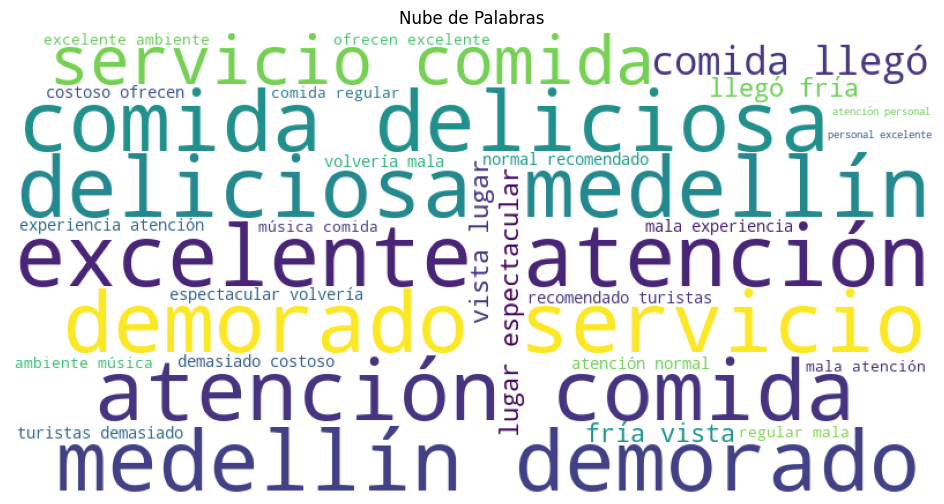

In [8]:

texto_total = " ".join(tokens_totales)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(texto_total)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("Nube de Palabras")

plt.show()



# Parte B · TF-IDF y analisis estadistico


In [9]:

# TF-IDF

vectorizer = TfidfVectorizer(max_features=3000)

X_tfidf = vectorizer.fit_transform(df["review"])

print(X_tfidf.shape)


(250, 37)


In [10]:

# TF crudo

count_vectorizer = CountVectorizer()

X_count = count_vectorizer.fit_transform(df["review"])

frecuencias_tf = np.array(X_count.sum(axis=0)).flatten()

palabras_tf = count_vectorizer.get_feature_names_out()

top_tf = pd.DataFrame({
    "palabra": palabras_tf,
    "frecuencia": frecuencias_tf
})

top_tf.sort_values(
    by="frecuencia",
    ascending=False
).head(15)


,palabra,frecuencia
17,la,100
23,muy,100
1,atención,75
2,comida,75
4,del,50
28,para,50
13,excelente,50
21,mala,50
0,ambiente,25
3,costoso,25


In [11]:

# Top TF-IDF

tfidf_scores = np.asarray(
    X_tfidf.mean(axis=0)
).ravel()

palabras_tfidf = vectorizer.get_feature_names_out()

top_tfidf = pd.DataFrame({
    "palabra": palabras_tfidf,
    "tfidf": tfidf_scores
})

top_tfidf.sort_values(
    by="tfidf",
    ascending=False
).head(15)


,palabra,tfidf
23,muy,0.120317
17,la,0.119795
1,atención,0.110185
2,comida,0.098863
13,excelente,0.086232
21,mala,0.085258
4,del,0.081028
28,para,0.079500
0,ambiente,0.061661
24,música,0.061661



## Reflexion TF vs TF-IDF

Con TF se observan principalmente las palabras que mas se repiten en las reseñas. 
El problema es que muchas veces esas palabras aparecen en casi todos los comentarios y realmente no ayudan a diferenciar opiniones positivas o negativas.

En cambio TF-IDF le da mas importancia a palabras que son menos comunes pero mas representativas dentro de ciertas reseñas por eso el anslisis con TF-IDF resulta mas util para clasificacion de sentimientos.



# Parte C · Clasificacion con TF-IDF


In [12]:

# Variable objetivo

y = df["sentimiento"]


In [13]:

# División train/test

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)


(200, 37)
(50, 37)


In [14]:

# Regresión Logística

modelo = LogisticRegression(max_iter=1000)

modelo.fit(X_train, y_train)

predicciones = modelo.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predicciones))

print(
    "F1 Score:",
    f1_score(y_test, predicciones, average='weighted')
)


Accuracy: 1.0
F1 Score: 1.0


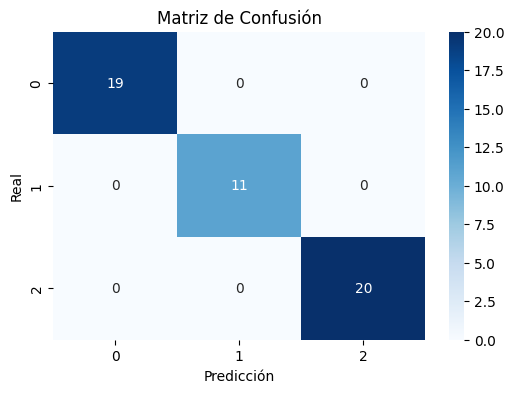

In [15]:

# Matriz de confusión

matriz = confusion_matrix(y_test, predicciones)

plt.figure(figsize=(6,4))

sns.heatmap(
    matriz,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Matriz de Confusión")

plt.xlabel("Predicción")

plt.ylabel("Real")

plt.show()


##  matriz de confusion

La matriz de confusion muestra que el modelo clasifico correctamente todas las observaciones del conjunto de prueba las 19 observaciones de la clase 0 fueron clasificadas correctamente y las 11 de la clase 1 tambien se predijeron de forma correcta y lo mismo ocurrio con las 20 observaciones de la clase 2. No hubo errores de clasificacion entre categorias.

Esto indica que el modelo obtuvo un desempeño extremadamente alto sobre el conjunto evaluado sin embargo, tambien considero que el resultado puede estar influenciado por el tamaño del dataset y por la repetición de varias reseñas similares dentro de los docuemntos  lo que hace que el problema de clasificacion sea ms sencillo para el modelo.



In [16]:

# Reporte de clasificación

print(
    classification_report(
        y_test,
        predicciones
    )
)


              precision    recall  f1-score   support

    negativo       1.00      1.00      1.00        19
     neutral       1.00      1.00      1.00        11
    positivo       1.00      1.00      1.00        20

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50




# Palabras predictoras


In [17]:

feature_names = vectorizer.get_feature_names_out()

for i, clase in enumerate(modelo.classes_):

    top = np.argsort(modelo.coef_[i])[-10:]

    print(f"\nClase: {clase}")

    print([feature_names[j] for j in top])



Clase: negativo
['demasiado', 'costoso', 'fría', 'demorado', 'el', 'servicio', 'llegó', 'muy', 'personal', 'mala']

Clase: neutral
['demasiado', 'que', 'costoso', 'atención', 'comida', 'la', 'fue', 'normal', 'estuvo', 'regular']

Clase: positivo
['en', 'ambiente', 'música', 'lugar', 'es', 'espectacular', 'vista', 'turistas', 'recomendado', 'excelente']



# Parte D · Modelo pre-entrenado de Hugging Face


In [18]:

# Pipeline Hugging Face

clasificador_hf = pipeline(
    "sentiment-analysis",
    model="pysentimiento/robertuito-sentiment-analysis"
)


c:\Users\Josue\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Josue\.cache\huggingface\hub\models--pysentimiento--robertuito-sentiment-analysis. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 3220.18it/s]


In [19]:

# Aplicar modelo Hugging Face

muestra = df["review"].head(20)

resultados_hf = clasificador_hf(list(muestra))

resultados_hf[:5]


[{'label': 'POS', 'score': 0.9719058871269226},
 {'label': 'NEG', 'score': 0.9557191729545593},
 {'label': 'POS', 'score': 0.9722756743431091},
 {'label': 'NEG', 'score': 0.787718653678894},
 {'label': 'NEU', 'score': 0.7683230042457581}]


# Comparación de modelos

Durante el ejercicio note que el modelo basado en TF-IDF funciona bastante bien para identificar patrones simples en las reseñas y ademas es rapido de entrenar.

Por otro lado, el modelo de Hugging Face logra entender mejor el contexto de algunas frases especialmente cuando hay expresiones ambiguas, negaciones o comentarios mas complejos.

Aunque ambos modelos tienen buenos resultados el modelo pre-entrenado parece captar mejor el lenguaje natural de las opiniones.



# Casos difíciles


In [20]:

casos_dificiles = [
    "Qué maravilla esperar dos horas por una hamburguesa",
    "La comida no estuvo tan mal",
    "Excelente servicio aunque demasiado caro",
    "Muy bonito el lugar pero pésima atención",
    "Volvería solo por la vista"
]

clasificador_hf(casos_dificiles)


[{'label': 'POS', 'score': 0.6091623902320862},
 {'label': 'POS', 'score': 0.7459594011306763},
 {'label': 'NEU', 'score': 0.5631589889526367},
 {'label': 'NEG', 'score': 0.5694065093994141},
 {'label': 'NEU', 'score': 0.743190586566925}]


# Conclusiones

En este trabajo pude entender como se aplican tecnicas de NLP sobre textos reales de reseñas.

La limpieza de texto y la tokenizacion fueron importantes para organizar mejor la informacion antes de entrenar los modelos tambienn observe que TF-IDF ayuda bastante a representar las palabras mas importantes dentro de las reseñas

El modelo de Regresion Logistica tuvo buenos resultados y permitio interpretar cuales palabras estaban mas relacionadas con opiniones positivas o negativas, finalmente, el modelo de Hugging Face mostro una mejor comprension del contexto y de comentarios dificiles, aunque requiere de  mas recursos.

